In [ ]:
!pip -q install openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.linear_model import MultiTaskLasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.svm import SVR

In [ ]:
df = pd.read_excel("ENB2012_data.xlsx")
df.head(), df.shape

(     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
 0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
 1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
 2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
 3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
 4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28,
 (768, 10))

In [ ]:
df.columns = [
    "Relative_Compactness",
    "Surface_Area",
    "Wall_Area",
    "Roof_Area",
    "Overall_Height",
    "Orientation",
    "Glazing_Area",
    "Glazing_Area_Distribution",
    "Heating_Load",
    "Cooling_Load"
]

df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [ ]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)

# Missing values
print("\nMissing values:\n", df.isnull().sum())

Shape: (768, 10)

Data types:
 Relative_Compactness         float64
Surface_Area                 float64
Wall_Area                    float64
Roof_Area                    float64
Overall_Height               float64
Orientation                    int64
Glazing_Area                 float64
Glazing_Area_Distribution      int64
Heating_Load                 float64
Cooling_Load                 float64
dtype: object

Missing values:
 Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64


In [ ]:
# Descriptive statistics
desc = df.describe().T
desc

,count,mean,std,min,25%,50%,75%,max
Relative_Compactness,768.0,0.764167,0.105777,0.62,0.6825,0.75,0.8300,0.98
Surface_Area,768.0,671.708333,88.086116,514.50,606.3750,673.75,741.1250,808.50
Wall_Area,768.0,318.500000,43.626481,245.00,294.0000,318.50,343.0000,416.50
Roof_Area,768.0,176.604167,45.165950,110.25,140.8750,183.75,220.5000,220.50
Overall_Height,768.0,5.250000,1.751140,3.50,3.5000,5.25,7.0000,7.00
Orientation,768.0,3.500000,1.118763,2.00,2.7500,3.50,4.2500,5.00
Glazing_Area,768.0,0.234375,0.133221,0.00,0.1000,0.25,0.4000,0.40
Glazing_Area_Distribution,768.0,2.812500,1.550960,0.00,1.7500,3.00,4.0000,5.00
Heating_Load,768.0,22.307195,10.090204,6.01,12.9925,18.95,31.6675,43.10
Cooling_Load,768.0,24.587760,9.513306,10.90,15.6200,22.08,33.1325,48.03


In [ ]:
X = df.drop(columns=["Heating_Load", "Cooling_Load"])
y = df[["Heating_Load", "Cooling_Load"]]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (768, 8)
y shape: (768, 2)


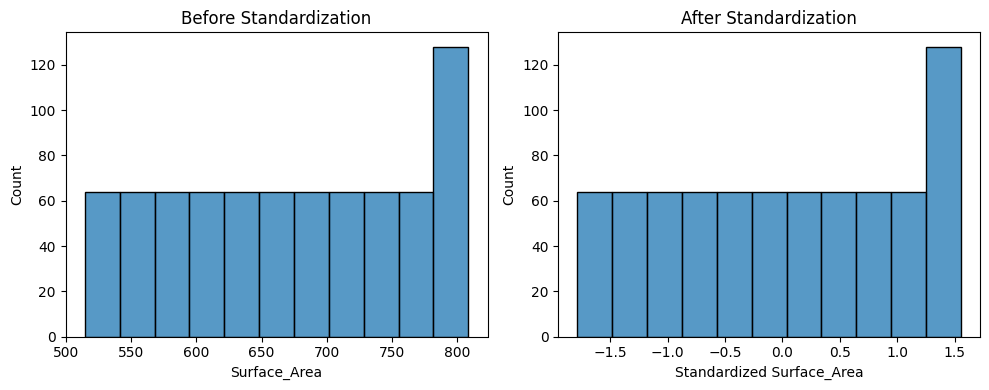

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

feature = df["Surface_Area"]

scaler = StandardScaler()
scaled = scaler.fit_transform(feature.values.reshape(-1,1))

fig, ax = plt.subplots(1,2, figsize=(10,4))

# Before scaling
sns.histplot(feature, ax=ax[0])
ax[0].set_title("Before Standardization")
ax[0].set_xlabel("Surface_Area")
ax[0].set_ylabel("Count")

# After scaling
sns.histplot(scaled.flatten(), ax=ax[1])
ax[1].set_title("After Standardization")
ax[1].set_xlabel("Standardized Surface_Area")   # <- thêm dòng này
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

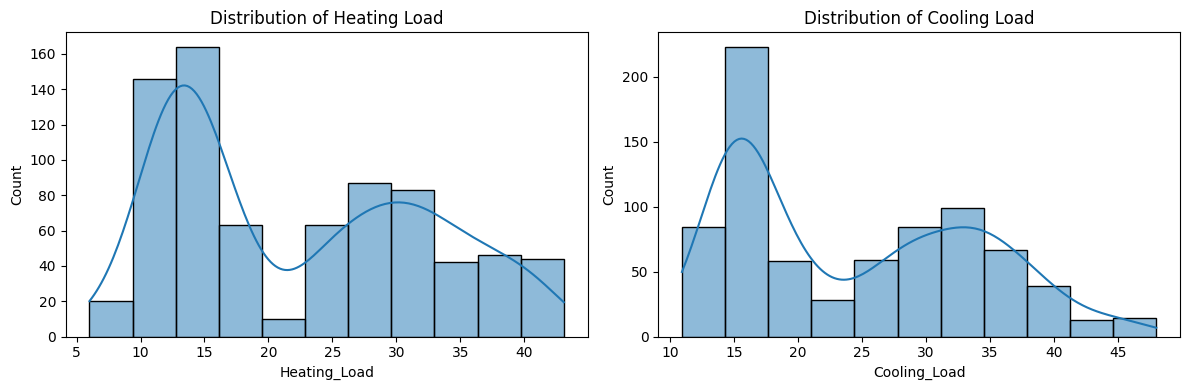

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["Heating_Load"], kde=True, ax=axes[0])
axes[0].set_title("Distribution of Heating Load")

sns.histplot(df["Cooling_Load"], kde=True, ax=axes[1])
axes[1].set_title("Distribution of Cooling Load")

plt.tight_layout()
plt.show()

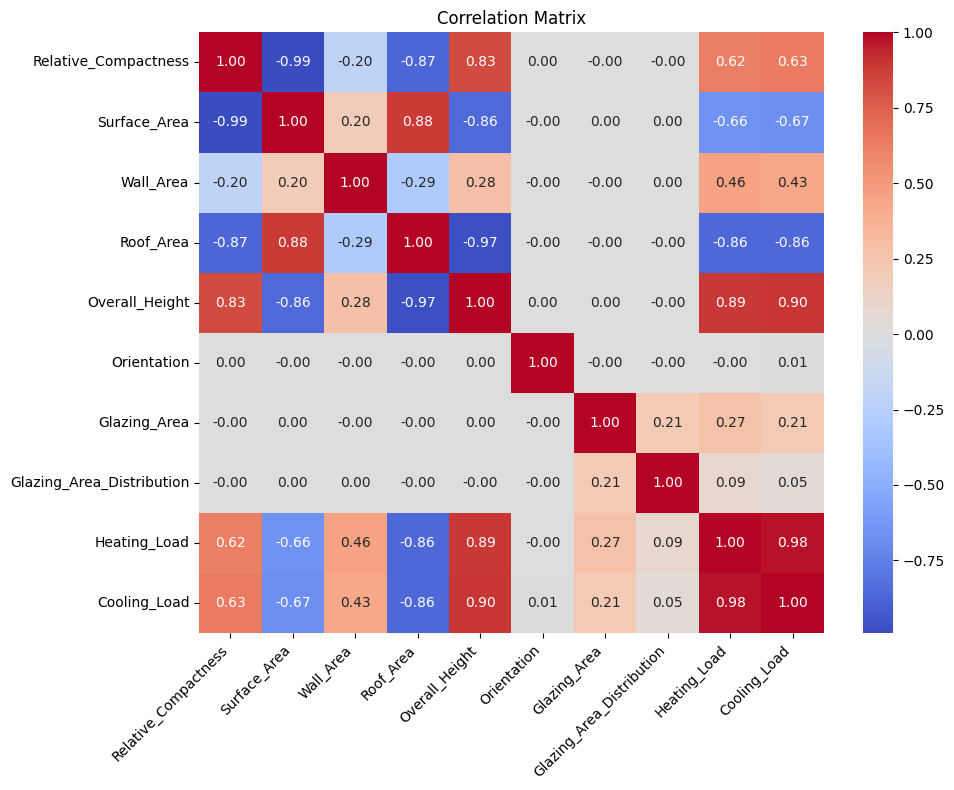

In [ ]:
plt.figure(figsize=(10,8))

corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

# xoay chữ cho dễ nhìn
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

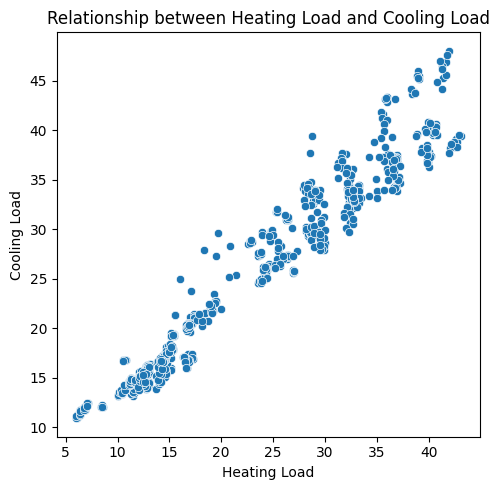

In [ ]:
plt.figure(figsize=(5,5))

sns.scatterplot(
    x=df["Heating_Load"],
    y=df["Cooling_Load"]
)

plt.xlabel("Heating Load")
plt.ylabel("Cooling Load")
plt.title("Relationship between Heating Load and Cooling Load")

plt.tight_layout()
plt.show()

In [ ]:
print("Correlation between Heating_Load and Cooling_Load:",
      corr.loc["Heating_Load", "Cooling_Load"])

Correlation between Heating_Load and Cooling_Load: 0.9758617391437702


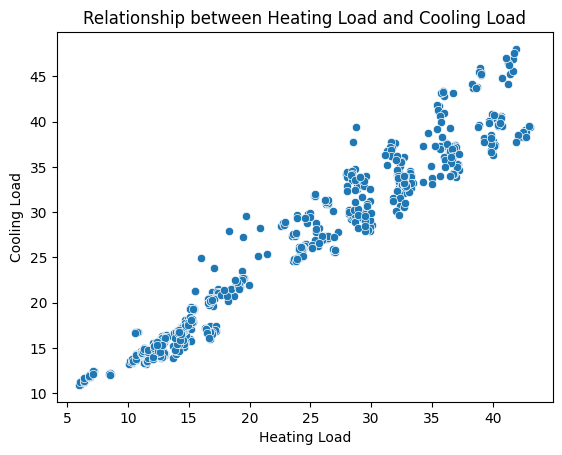

In [ ]:
sns.scatterplot(
    x=df["Heating_Load"],
    y=df["Cooling_Load"]
)

plt.title("Relationship between Heating Load and Cooling Load")
plt.xlabel("Heating Load")
plt.ylabel("Cooling Load")

plt.show()

In [ ]:
def count_iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = series[(series < lower) | (series > upper)]
    return len(outliers), lower, upper

for col in ["Heating_Load", "Cooling_Load"]:
    count, lower, upper = count_iqr_outliers(df[col])
    print(f"{col}: {count} samples outside 1.5 IQR")

Heating_Load: 0 samples outside 1.5 IQR
Cooling_Load: 0 samples outside 1.5 IQR


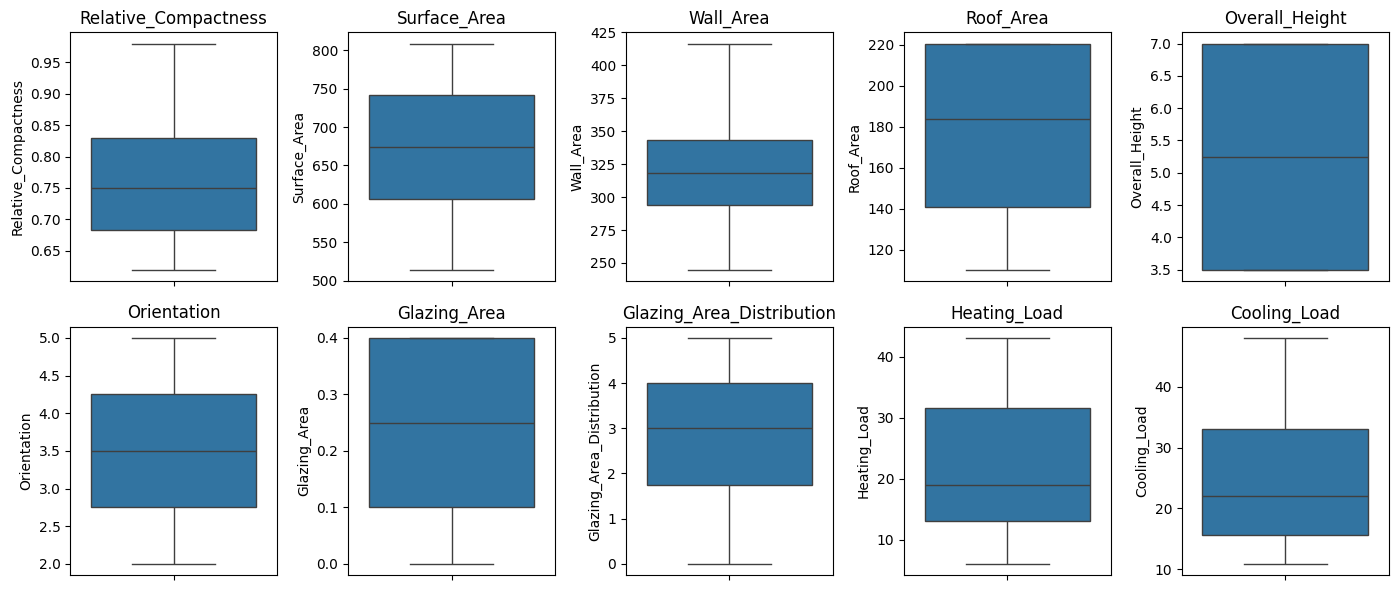

In [ ]:
plt.figure(figsize=(14,6))

for i, col in enumerate(df.columns):

    plt.subplot(2,5,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#THỰC NGHIỆM

##Chia train/test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (614, 8)
X_test: (154, 8)
y_train: (614, 2)
y_test: (154, 2)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##Tách HL và CL cho single-output models

In [ ]:
y_train_HL = y_train["Heating_Load"]
y_train_CL = y_train["Cooling_Load"]

y_test_HL = y_test["Heating_Load"]
y_test_CL = y_test["Cooling_Load"]

##Metrics

In [ ]:
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return mae, rmse

##1. Model OLS

In [ ]:
#Train model cho Heating Load
ols_HL = LinearRegression()

ols_HL.fit(X_train_scaled, y_train_HL)

pred_HL = ols_HL.predict(X_test_scaled)

ols_mae_hl, ols_rmse_hl = evaluate(y_test_HL, pred_HL)

print("OLS - Heating Load")
print("MAE:", ols_mae_hl)
print("RMSE:", ols_rmse_hl)

OLS - Heating Load
MAE: 2.1820729961538965
RMSE: 3.0254268535103725


In [ ]:
#Train model cho Cooling Load
ols_CL = LinearRegression()

ols_CL.fit(X_train_scaled, y_train_CL)

pred_CL = ols_CL.predict(X_test_scaled)

ols_mae_cl, ols_rmse_cl = evaluate(y_test_CL, pred_CL)

print("OLS - Cooling Load")
print("MAE:", ols_mae_cl)
print("RMSE:", ols_rmse_cl)

OLS - Cooling Load
MAE: 2.1952952105158734
RMSE: 3.145381955811419


##2. Model Ridge Regression

In [ ]:
alphas = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

In [ ]:
ridge_HL = GridSearchCV(
    Ridge(),
    param_grid=alphas,
    cv=5,
    scoring="neg_mean_squared_error"
)

ridge_HL.fit(X_train_scaled, y_train_HL)

print("Best alpha:", ridge_HL.best_params_)

Best alpha: {'alpha': 0.1}


In [ ]:
pred_HL = ridge_HL.predict(X_test_scaled)

ridge_mae_HL, ridge_rmse_HL = evaluate(y_test_HL, pred_HL)

print("Ridge - Heating Load")
print("MAE:", ridge_mae_HL)
print("RMSE:", ridge_rmse_HL)

Ridge - Heating Load
MAE: 2.182897947019781
RMSE: 3.0263704473584445


In [ ]:
ridge_CL = GridSearchCV(
    Ridge(),
    param_grid=alphas,
    cv=5,
    scoring="neg_mean_squared_error"
)

ridge_CL.fit(X_train_scaled, y_train_CL)

print("Best alpha:", ridge_CL.best_params_)

Best alpha: {'alpha': 0.1}


In [ ]:
pred_CL = ridge_CL.predict(X_test_scaled)

ridge_mae_CL, ridge_rmse_CL = evaluate(y_test_CL, pred_CL)

print("Ridge - Cooling Load")
print("MAE:", ridge_mae_CL)
print("RMSE:", ridge_rmse_CL)

Ridge - Cooling Load
MAE: 2.1948795859622425
RMSE: 3.145717299544775


##3. Model Lasso Regression

In [ ]:
alphas = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}

lasso_HL = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid=alphas,
    cv=5,
    scoring="neg_mean_squared_error"
)

lasso_HL.fit(X_train_scaled, y_train_HL)

print("Best alpha:", lasso_HL.best_params_)

pred_HL = lasso_HL.predict(X_test_scaled)

lasso_mae_HL, lasso_rmse_HL = evaluate(y_test_HL, pred_HL)

print("Lasso - Heating Load")
print("MAE:", lasso_mae_HL)
print("RMSE:", lasso_rmse_HL)

Best alpha: {'alpha': 0.001}
Lasso - Heating Load
MAE: 2.1831800768269876
RMSE: 3.0262490075222357


In [ ]:
lasso_CL = GridSearchCV(
    Lasso(max_iter=10000),
    param_grid=alphas,
    cv=5,
    scoring="neg_mean_squared_error"
)

lasso_CL.fit(X_train_scaled, y_train_CL)

print("Best alpha:", lasso_CL.best_params_)

pred_CL = lasso_CL.predict(X_test_scaled)

lasso_mae_CL, lasso_rmse_CL = evaluate(y_test_CL, pred_CL)

print("Lasso - Cooling Load")
print("MAE:", lasso_mae_CL)
print("RMSE:", lasso_rmse_CL)

Best alpha: {'alpha': 0.001}
Lasso - Cooling Load
MAE: 2.194522931334341
RMSE: 3.1455095332889935


##4. Multi output Ridge

In [ ]:
mo_ridge = GridSearchCV(
    Ridge(),
    param_grid={"alpha": [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=5,
    scoring="neg_mean_squared_error"
)

mo_ridge.fit(X_train_scaled, y_train)

print("Best alpha:", mo_ridge.best_params_)

Best alpha: {'alpha': 0.1}


In [ ]:
pred_mo_ridge = mo_ridge.predict(X_test_scaled)

print(pred_mo_ridge.shape)

(154, 2)


In [ ]:
mo_ridge_mae_HL, mo_ridge_rmse_HL = evaluate(y_test["Heating_Load"], pred_mo_ridge[:, 0])
mo_ridge_mae_CL, mo_ridge_rmse_CL = evaluate(y_test["Cooling_Load"], pred_mo_ridge[:, 1])

print("Multi-output Ridge - Heating Load")
print("MAE:", mo_ridge_mae_HL)
print("RMSE:", mo_ridge_rmse_HL)

print("\nMulti-output Ridge - Cooling Load")
print("MAE:", mo_ridge_mae_CL)
print("RMSE:", mo_ridge_rmse_CL)

Multi-output Ridge - Heating Load
MAE: 2.182897947019781
RMSE: 3.0263704473584463

Multi-output Ridge - Cooling Load
MAE: 2.1948795859622448
RMSE: 3.145717299544777


##5. Model Multi output Lasso

In [ ]:
from sklearn.linear_model import MultiTaskLasso

mo_lasso = GridSearchCV(
    MultiTaskLasso(max_iter=10000),
    param_grid={"alpha": [0.001, 0.01, 0.1, 1, 10]},
    cv=5,
    scoring="neg_mean_squared_error"
)

mo_lasso.fit(X_train_scaled, y_train)

print("Best alpha:", mo_lasso.best_params_)

pred_mo_lasso = mo_lasso.predict(X_test_scaled)

print(pred_mo_lasso.shape)

Best alpha: {'alpha': 0.001}
(154, 2)


In [ ]:
mo_lasso_mae_HL, mo_lasso_rmse_HL = evaluate(y_test["Heating_Load"], pred_mo_lasso[:, 0])
mo_lasso_mae_CL, mo_lasso_rmse_CL = evaluate(y_test["Cooling_Load"], pred_mo_lasso[:, 1])

print("Multi-output Lasso - Heating Load")
print("MAE:", mo_lasso_mae_HL)
print("RMSE:", mo_lasso_rmse_HL)

print("\nMulti-output Lasso - Cooling Load")
print("MAE:", mo_lasso_mae_CL)
print("RMSE:", mo_lasso_rmse_CL)

Multi-output Lasso - Heating Load
MAE: 2.182751621254026
RMSE: 3.025946318882657

Multi-output Lasso - Cooling Load
MAE: 2.194749763357099
RMSE: 3.145482411650202


##6. Linear SVR

In [ ]:
svr_linear_grid = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.5, 1.0]
}

In [ ]:
linear_svr_HL = GridSearchCV(
    SVR(kernel="linear"),
    param_grid=svr_linear_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

linear_svr_HL.fit(X_train_scaled, y_train_HL)

print("Best params:", linear_svr_HL.best_params_)

Best params: {'C': 10, 'epsilon': 1.0}


In [ ]:
pred_HL = linear_svr_HL.predict(X_test_scaled)

linear_svr_mae_HL, linear_svr_rmse_HL = evaluate(y_test_HL, pred_HL)

print("Linear SVR - Heating Load")
print("MAE:", linear_svr_mae_HL)
print("RMSE:", linear_svr_rmse_HL)

Linear SVR - Heating Load
MAE: 2.1250189709287732
RMSE: 3.067933107980184


In [ ]:
linear_svr_CL = GridSearchCV(
    SVR(kernel="linear"),
    param_grid=svr_linear_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

linear_svr_CL.fit(X_train_scaled, y_train_CL)

print("Best params:", linear_svr_CL.best_params_)

Best params: {'C': 10, 'epsilon': 1.0}


In [ ]:
pred_CL = linear_svr_CL.predict(X_test_scaled)

linear_svr_mae_CL, linear_svr_rmse_CL = evaluate(y_test_CL, pred_CL)

print("Linear SVR - Cooling Load")
print("MAE:", linear_svr_mae_CL)
print("RMSE:", linear_svr_rmse_CL)

Linear SVR - Cooling Load
MAE: 2.1776387572653397
RMSE: 3.2797245372431902


##7. Model RBF SVR

In [ ]:
svr_rbf_grid = {
    "C": [1, 10, 100, 1000],
    "epsilon": [0.01, 0.1, 0.5, 1.0],
    "gamma": ["scale", "auto", 0.01, 0.1, 1]
}

In [ ]:
rbf_svr_HL = GridSearchCV(
    SVR(kernel="rbf"),
    param_grid=svr_rbf_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rbf_svr_HL.fit(X_train_scaled, y_train_HL)

print("Best params:", rbf_svr_HL.best_params_)

Best params: {'C': 1000, 'epsilon': 0.1, 'gamma': 0.1}


In [ ]:
pred_HL = rbf_svr_HL.predict(X_test_scaled)

rbf_svr_mae_HL, rbf_svr_rmse_HL = evaluate(y_test_HL, pred_HL)

print("RBF SVR - Heating Load")
print("MAE:", rbf_svr_mae_HL)
print("RMSE:", rbf_svr_rmse_HL)

RBF SVR - Heating Load
MAE: 0.3415607475130083
RMSE: 0.46632297847379844


In [ ]:
rbf_svr_CL = GridSearchCV(
    SVR(kernel="rbf"),
    param_grid=svr_rbf_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rbf_svr_CL.fit(X_train_scaled, y_train_CL)

print("Best params:", rbf_svr_CL.best_params_)

Best params: {'C': 1000, 'epsilon': 0.1, 'gamma': 0.1}


In [ ]:
pred_CL = rbf_svr_CL.predict(X_test_scaled)

rbf_svr_mae_CL, rbf_svr_rmse_CL = evaluate(y_test_CL, pred_CL)

print("RBF SVR - Cooling Load")
print("MAE:", rbf_svr_mae_CL)
print("RMSE:", rbf_svr_rmse_CL)

RBF SVR - Cooling Load
MAE: 0.9127526041383044
RMSE: 1.5500157793550944


In [ ]:
results = pd.DataFrame({
    "Model": [
        "OLS",
        "Ridge",
        "Lasso",
        "Multi-output Ridge",
        "Multi-output Lasso",
        "Linear SVR",
        "RBF SVR"
    ],

    "HL_MAE": [
        ols_mae_hl,
        ridge_mae_HL,
        lasso_mae_HL,
        mo_ridge_mae_HL,
        mo_lasso_mae_HL,
        linear_svr_mae_HL,
        rbf_svr_mae_HL
    ],

    "HL_RMSE": [
        ols_rmse_hl,
        ridge_rmse_HL,
        lasso_rmse_HL,
        mo_ridge_rmse_HL,
        mo_lasso_rmse_HL,
        linear_svr_rmse_HL,
        rbf_svr_rmse_HL
    ],

    "CL_MAE": [
        ols_mae_cl,
        ridge_mae_CL,
        lasso_mae_CL,
        mo_ridge_mae_CL,
        mo_lasso_mae_CL,
        linear_svr_mae_CL,
        rbf_svr_mae_CL
    ],

    "CL_RMSE": [
        ols_rmse_cl,
        ridge_rmse_CL,
        lasso_rmse_CL,
        mo_ridge_rmse_CL,
        mo_lasso_rmse_CL,
        linear_svr_rmse_CL,
        rbf_svr_rmse_CL
    ]
})

results.round(4)

,Model,HL_MAE,HL_RMSE,CL_MAE,CL_RMSE
0,OLS,2.1821,3.0254,2.1953,3.1454
1,Ridge,2.1829,3.0264,2.1949,3.1457
2,Lasso,2.1832,3.0262,2.1945,3.1455
3,Multi-output Ridge,2.1829,3.0264,2.1949,3.1457
4,Multi-output Lasso,2.1828,3.0259,2.1947,3.1455
5,Linear SVR,2.1250,3.0679,2.1776,3.2797
6,RBF SVR,0.3416,0.4663,0.9128,1.5500
